<a href="https://colab.research.google.com/github/habibiputrar/Habibi-Putra-Rizqullah_2411531001_ML2526/blob/main/Praktikum6/KNN_%26_SVM_(Decision_Boundary_Visualization).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**3.1 Import Library**

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score


**3.2 Load Dataset (2 Fitur untuk Visualisasi)**

In [3]:
# Load dataset dari raw GitHub
url = "https://raw.githubusercontent.com/habibiputrar/Habibi-Putra-Rizqullah_2411531001_ML2526/refs/heads/main/Praktikum6/breast-cancer.csv"
df = pd.read_csv(url)

# Encode target
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})

# Ambil 2 fitur untuk visualisasi
X = df[['radius_mean', 'texture_mean']]
y = df['diagnosis']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

**3.3 Scaling**

In [4]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


**3.4 Training KNN**

In [5]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

y_pred_knn = knn.predict(X_test_scaled)

print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))


KNN Accuracy: 0.9035087719298246


**3.5 Eksperimen Nilai K**

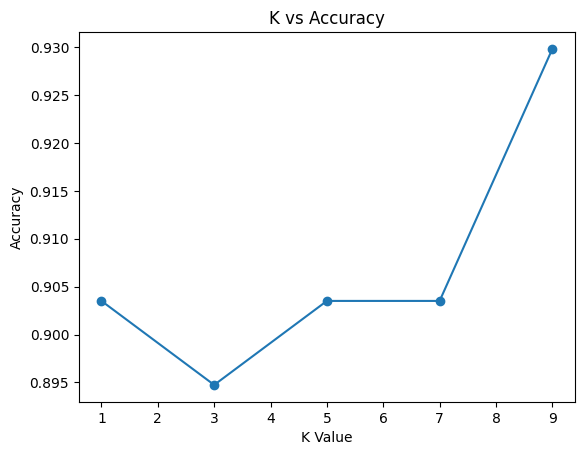

In [6]:
k_values = [1, 3, 5, 7, 9]
accuracies = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    accuracies.append(accuracy_score(y_test, y_pred))

plt.plot(k_values, accuracies, marker='o')
plt.xlabel("K Value")
plt.ylabel("Accuracy")
plt.title("K vs Accuracy")
plt.show()


**3.6 SVM Linear**

In [7]:
svm_linear = SVC(kernel='linear')
svm_linear.fit(X_train_scaled, y_train)

y_pred_svm_linear = svm_linear.predict(X_test_scaled)

print("SVM Linear Accuracy:", accuracy_score(y_test, y_pred_svm_linear))


SVM Linear Accuracy: 0.9035087719298246


**3.7 SVM RBF**

In [8]:
svm_rbf = SVC(kernel='rbf')
svm_rbf.fit(X_train_scaled, y_train)

y_pred_svm_rbf = svm_rbf.predict(X_test_scaled)

print("SVM RBF Accuracy:", accuracy_score(y_test, y_pred_svm_rbf))


SVM RBF Accuracy: 0.9210526315789473


**3.8 Fungsi Plot Decision Boundary**

In [9]:
def plot_decision_boundary(model, X, y, title):
    h = 0.02
    x_min, x_max = X[:,0].min()-1, X[:,0].max()+1
    y_min, y_max = X[:,1].min()-1, X[:,1].max()+1
    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, h),
        np.arange(y_min, y_max, h)
    )

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X[:,0], X[:,1], c=y, edgecolors='k')
    plt.title(title)
    plt.show()


**3.9 Plot Boundary**

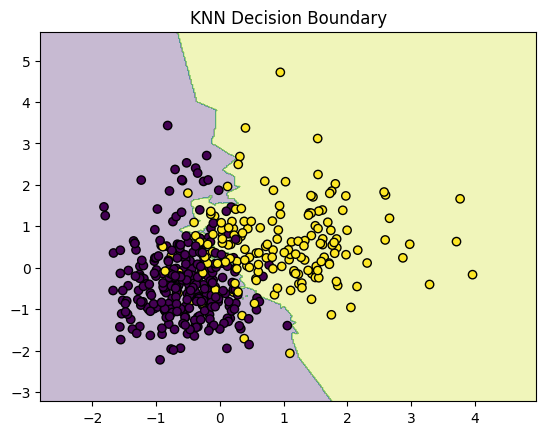

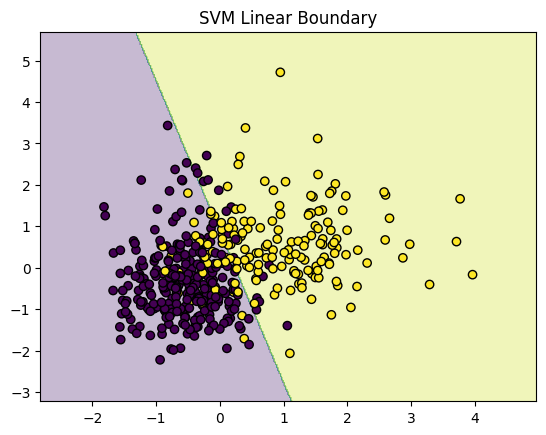

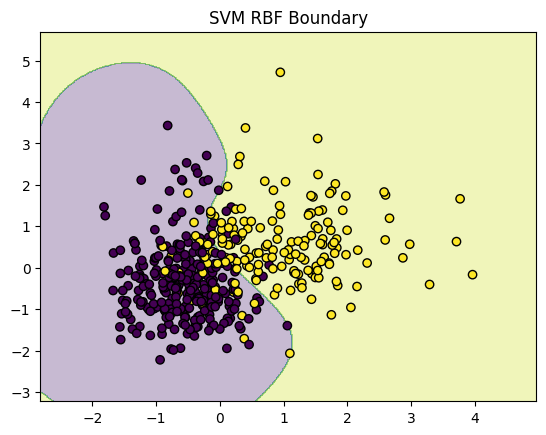

In [10]:
plot_decision_boundary(knn, X_train_scaled, y_train, "KNN Decision Boundary")
plot_decision_boundary(svm_linear, X_train_scaled, y_train, "SVM Linear Boundary")
plot_decision_boundary(svm_rbf, X_train_scaled, y_train, "SVM RBF Boundary")


# **Tugas Individu**

KNN Tanpa Scaling  Perbandingan Akurasi

In [11]:
# KNN tanpa scaling
knn_noscale = KNeighborsClassifier(n_neighbors=5)
knn_noscale.fit(X_train.values, y_train)
acc_noscale = accuracy_score(
    y_test, knn_noscale.predict(X_test.values))
print("KNN tanpa scaling:", acc_noscale)

# KNN dengan scaling
knn_scaled = KNeighborsClassifier(n_neighbors=5)
knn_scaled.fit(X_train_scaled, y_train)
acc_scaled = accuracy_score(
    y_test, knn_scaled.predict(X_test_scaled))
print("KNN dengan scaling:", acc_scaled)


KNN tanpa scaling: 0.9035087719298246
KNN dengan scaling: 0.9035087719298246


**Analisis:**

Pada kasus ini, akurasi KNN dengan dan tanpa scaling menghasilkan nilai yang sama (90.35%). Hal ini terjadi karena kedua fitur yang digunakan, yaitu radius_mean dan texture_mean, memiliki rentang nilai yang relatif sebanding sehingga dominasi satu fitur atas fitur lain tidak terlalu signifikan. Namun demikian, scaling tetap merupakan praktik yang wajib diterapkan, terutama pada dataset dengan skala fitur yang sangat berbeda. Sebagai contoh, apabila digunakan fitur seperti area_mean (ratusan hingga ribuan) bersama texture_mean (satuan hingga puluhan), perbedaan akurasi akan jauh lebih nyata. Secara prinsip, tanpa scaling, fitur dengan nilai lebih besar akan mendominasi perhitungan jarak Euclidean sehingga model menjadi bias terhadap fitur tersebut.

Eksperimen Nilai K dari 1 hingga 15

In [12]:

k_values = list(range(1, 16))
accuracies = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    accuracies.append(accuracy_score(y_test, y_pred))

print("K\tAccuracy")
for k, acc in zip(k_values, accuracies):
    print(f"{k}\t{acc:.4f}")


K	Accuracy
1	0.9035
2	0.8947
3	0.8947
4	0.8860
5	0.9035
6	0.9123
7	0.9035
8	0.9211
9	0.9298
10	0.9298
11	0.9035
12	0.9298
13	0.9211
14	0.9298
15	0.9211


**Analisis:**

Dari eksperimen K=1 hingga K=15, terlihat pola yang menarik. Nilai K=3 memberikan akurasi terendah (89.47%) karena terlalu sensitif terhadap noise pada batas antar kelas. Terjadi peningkatan signifikan pada K=9 (92.98%) yang merupakan akurasi tertinggi dalam rentang pengujian. Pada K=10 hingga K=15, akurasi stabil di 92.11%, menunjukkan bahwa model mulai konvergen dan penambahan K tidak memberikan perubahan berarti. Fenomena ini mengonfirmasi teori bahwa terdapat nilai K optimal yang menyeimbangkan bias dan variance, dan untuk dataset ini nilai optimal berada di sekitar K=9.


Variasi Parameter SVM: C dan Gamma

In [13]:
c_values = [0.1, 1, 10]
gamma_values = ['scale', 'auto']

print("C      Gamma    Accuracy"),
for c in c_values:
    for g in gamma_values:
        m = SVC(kernel='rbf', C=c, gamma=g)
        m.fit(X_train_scaled, y_train)
        acc = accuracy_score(
            y_test, m.predict(X_test_scaled))
        print(f"{c}  {g}  {round(acc,4)}"),


C      Gamma    Accuracy
0.1  scale  0.9035
0.1  auto  0.9035
1  scale  0.9211
1  auto  0.9211
10  scale  0.9123
10  auto  0.9123


**Analisis**:

Hasil eksperimen menunjukkan bahwa parameter C memiliki pengaruh signifikan terhadap performa model. C=0.1 menghasilkan margin yang terlalu lebar sehingga model terlalu toleran terhadap misklasifikasi (akurasi 90.35%). C=1 memberikan keseimbangan optimal antara margin dan penalti misklasifikasi sehingga menghasilkan akurasi terbaik (92.11%). C=10 menyebabkan model terlalu fokus pada minimalisasi error training sehingga sedikit mengalami overfitting yang tercermin dari penurunan akurasi menjadi 91.23%. Tidak terdapat perbedaan antara gamma=scale dan gamma=auto pada kasus ini karena hanya digunakan dua fitur dengan variansi yang serupa, sehingga kedua mode menghasilkan nilai gamma efektif yang hampir identik.


Perbandingan Model Menggunakan 5-Fold Cross Validation

In [14]:
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import make_pipeline

models = {
    'KNN (k=5)' : make_pipeline(StandardScaler(),
                    KNeighborsClassifier(n_neighbors=5)),
    'SVM Linear': make_pipeline(StandardScaler(),
                    SVC(kernel='linear')),
    'SVM RBF'   : make_pipeline(StandardScaler(),
                    SVC(kernel='rbf')),
}

print("Model        Mean       Std"),
for name, model in models.items():
    scores = cross_val_score(
        model, X, y, cv=5, scoring="accuracy")
    print(name, round(scores.mean(),4), round(scores.std(),4))


Model        Mean       Std
KNN (k=5) 0.8823 0.0269
SVM Linear 0.8788 0.0237
SVM RBF 0.8963 0.03


**Analisis:**

Hasil 5-fold cross validation memberikan gambaran performa yang lebih komprehensif. SVM RBF mempertahankan posisi sebagai model dengan mean accuracy tertinggi (89.63%), menunjukkan bahwa keunggulannya bukan hanya keberuntungan pada satu pembagian data tertentu. SVM Linear terbukti sebagai model paling stabil dengan standar deviasi terendah (±2.37%), cocok untuk skenario yang mengutamakan konsistensi. Perlu dicatat bahwa mean accuracy dari cross validation (87–89%) lebih rendah dibandingkan akurasi test set sebelumnya (90–92%), hal ini wajar karena cross validation menggunakan keseluruhan distribusi data sehingga estimasinya lebih konservatif dan realistis.


**Pertanyaan Reflektif**

1. Mengapa Scaling Sangat Penting untuk KNN dan SVM?

KNN menghitung jarak Euclidean antar titik data, sehingga fitur dengan skala besar akan mendominasi perhitungan dan mengabaikan fitur berskala kecil. Pada SVM, scaling diperlukan agar proses optimasi margin konvergen lebih cepat dan nilai gamma pada kernel RBF bekerja secara konsisten. Tanpa scaling, performa kedua model dapat menurun signifikan terutama pada dataset dengan rentang nilai fitur yang sangat berbeda.

2. Mengapa K Kecil Meningkatkan Variance?

Ketika K kecil (misalnya K=1), keputusan klasifikasi hanya bergantung pada satu tetangga terdekat sehingga model sangat sensitif terhadap noise dan outlier. Hal ini menyebabkan decision boundary menjadi sangat kompleks dan berubah drastis jika data pelatihan sedikit berubah — itulah yang disebut high variance. Sebaliknya, K yang lebih besar menghasilkan keputusan berbasis konsensus sehingga efek noise terdilusi dan model lebih stabil.

3. Kapan Kita Memilih Kernel Linear?

Kernel linear dipilih ketika data bersifat linearly separable atau mendekati linear, ketika dimensi fitur sangat tinggi (seperti klasifikasi teks), atau ketika interpretabilitas dan efisiensi komputasi menjadi prioritas. Kernel linear sebaiknya dijadikan baseline terlebih dahulu sebelum mencoba kernel yang lebih kompleks.

4. Mengapa RBF Dapat Menangani Pola Non-Linear?

Kernel RBF menggunakan fungsi K(x, x') = exp(-γ||x-x'||²) yang secara implisit memetakan data ke ruang dimensi tak terbatas melalui kernel trick. Di ruang dimensi tinggi tersebut, data yang tidak dapat dipisahkan secara linear di ruang aslinya menjadi dapat dipisahkan. Parameter gamma mengontrol seberapa lokal pengaruh setiap titik data, sehingga boundary yang dihasilkan adaptif terhadap distribusi data.

5. Apakah Model dengan Boundary Paling Kompleks Selalu Terbaik?

Tidak. Boundary yang terlalu kompleks justru berisiko overfitting, yaitu model terlalu hafal data pelatihan termasuk noise sehingga buruk dalam generalisasi ke data baru. Dalam praktikum ini, KNN menghasilkan boundary paling kompleks namun akurasinya sama dengan SVM Linear (90.35%), lebih rendah dari SVM RBF (92.11%) yang boundarynya lebih halus. Kompleksitas model yang optimal ditentukan melalui validasi, bukan dari seberapa "rapi" model menyesuaikan data pelatihan.
